LSTM Model only Revenue data

Train length: 1461
Test length : 320
X_train shape: (1431, 30, 1)
X_test shape : (320, 30, 1)
Using device: cpu
Epoch 1/50 - Train Loss: 0.026396
Epoch 10/50 - Train Loss: 0.009331
Epoch 20/50 - Train Loss: 0.007844
Epoch 30/50 - Train Loss: 0.006778
Epoch 40/50 - Train Loss: 0.006531
Epoch 50/50 - Train Loss: 0.006523

--- METRIKEN (PyTorch LSTM) ---
MSE          : 16189225.82
RMSE         : 4023.58
R²           : 0.5620
MAE          : 3042.26
Relative MSE : 0.4869
MAPE         : 30.61%


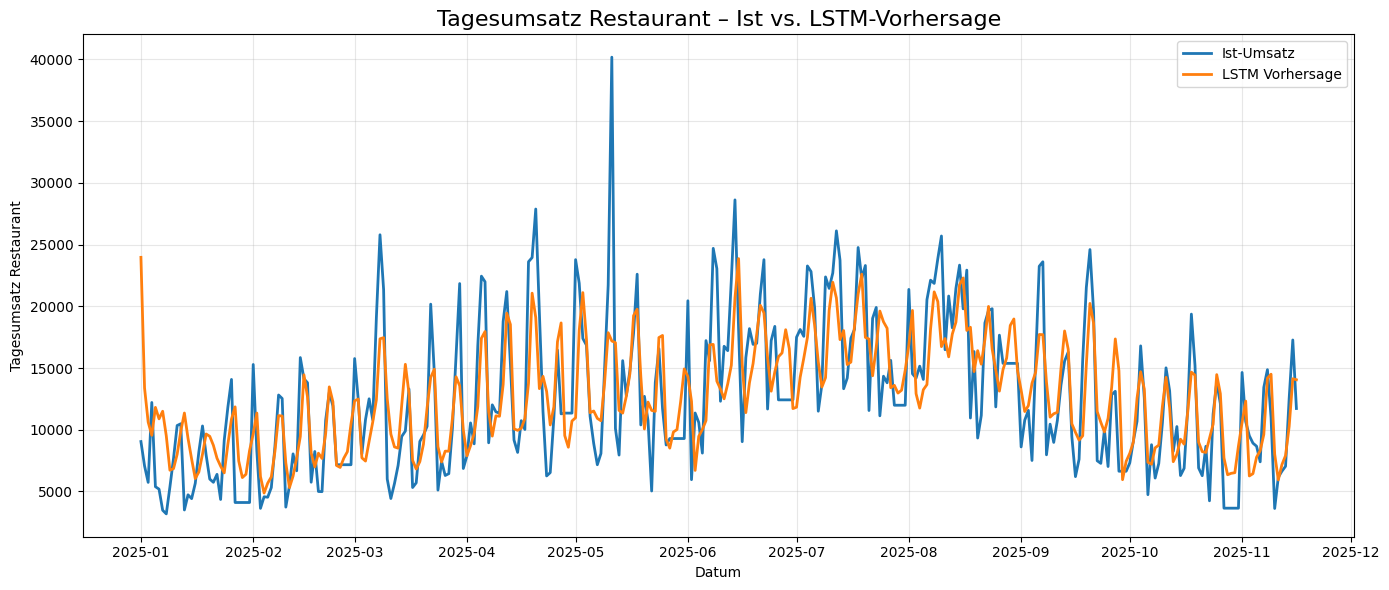

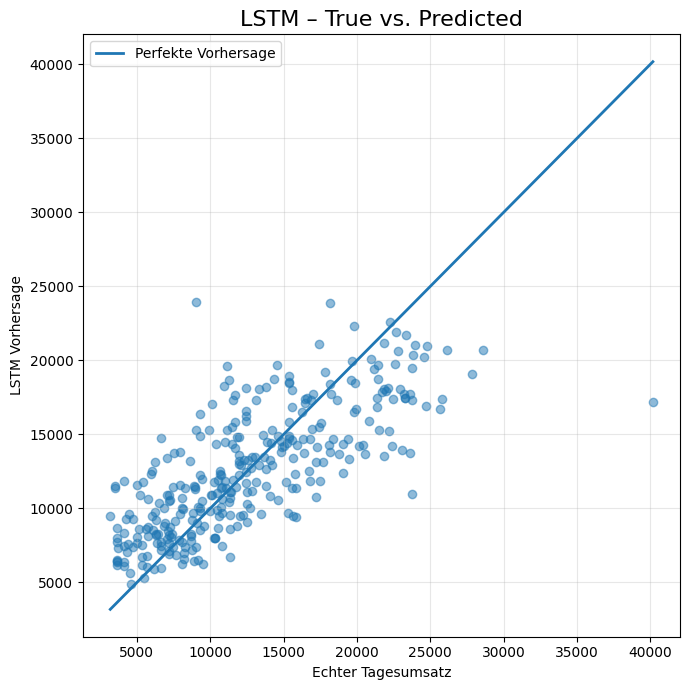

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ===================== 1) Daten laden & vorbereiten =====================

df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Univariate Zeitreihe
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# tägliche Frequenz & Lücken füllen
ts = ts.asfreq("D")
ts = ts.ffill().bfill()

# Train/Test-Split
split_date = pd.Timestamp("2025-01-01")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# Skaler nur auf Train anpassen
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

# gesamte Serie mit demselben Skaler transformieren
full_scaled = scaler.transform(ts.values.reshape(-1, 1)).flatten()
dates = ts.index

# ===================== 2) Sliding-Window-Datensatz =====================

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
dates_test = []

for i in range(window_size, len(full_scaled)):
    X_seq = full_scaled[i - window_size:i]
    y_target = full_scaled[i]
    target_date = dates[i]

    if target_date < split_date:
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    else:
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

# LSTM-Input: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# ===================== 3) PyTorch Dataset & DataLoader =====================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

# ===================== 4) LSTM-Modell definieren =====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===================== 5) Training =====================

epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Train Loss: {epoch_loss:.6f}")

# ===================== 6) Vorhersage auf Testset =====================

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# ===================== 7) Metriken =====================

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

# naive Baseline: Vortag
ts_shifted = ts.shift(1)
y_naive = ts_shifted.loc[dates_test].values
y_naive = pd.Series(y_naive, index=dates_test).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred)

print("\n--- METRIKEN (PyTorch LSTM) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ===================== 8) Plots =====================

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label="Ist-Umsatz", linewidth=2)
plt.plot(dates_test, y_pred, label="LSTM Vorhersage", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


LSTM Model with Features

Feature-Spalten: ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)', 'Tagesumsatz Restaurant']
Zielvariable   : Tagesumsatz Restaurant
Train length (Tage): 1461
Test length  (Tage): 320
X_train shape: (1431, 30, 8)
X_test shape : (320, 30, 8)
Anzahl Features: 8
Using device: cpu
Epoch 1/50 - Train Loss: 0.027700
Epoch 10/50 - Train Loss: 0.006640
Epoch 20/50 - Train Loss: 0.005817
Epoch 30/50 - Train Loss: 0.005790
Epoch 40/50 - Train Loss: 0.005220
Epoch 50/50 - Train Loss: 0.004718

--- METRIKEN (PyTorch LSTM mit Features) ---
MSE          : 16298028.59
RMSE         : 4037.08
R²           : 0.5591
MAE          : 2920.22
Relative MSE : 0.4902
MAPE         : 25.84%


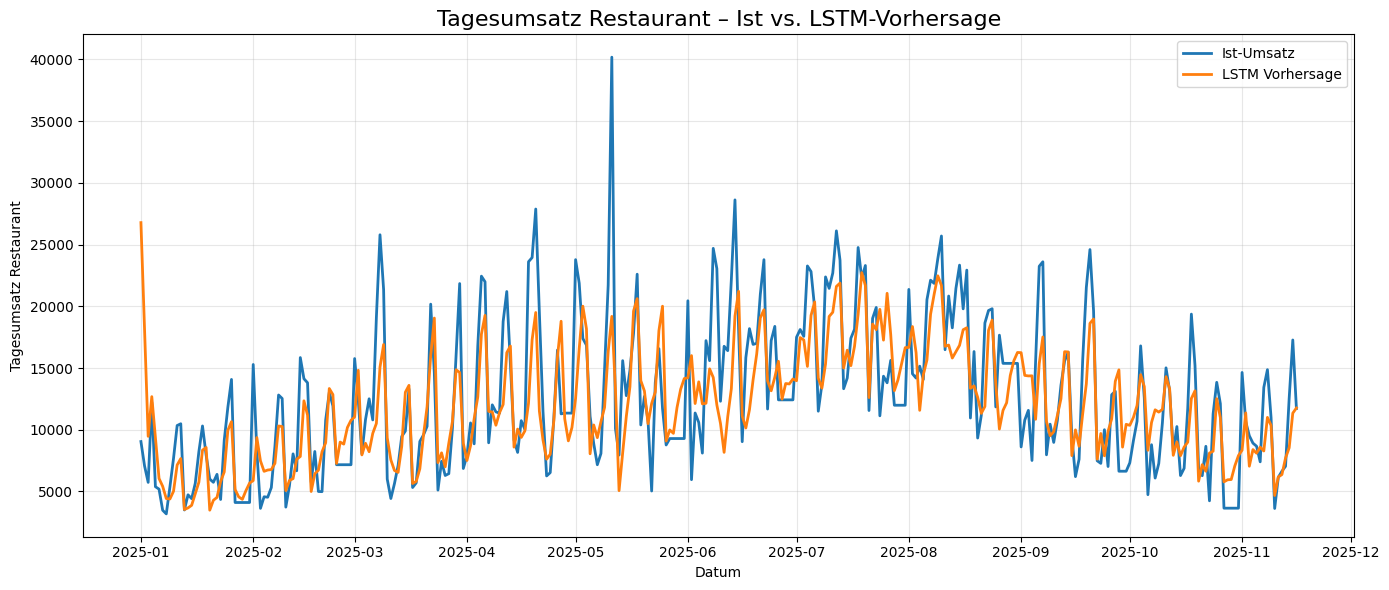

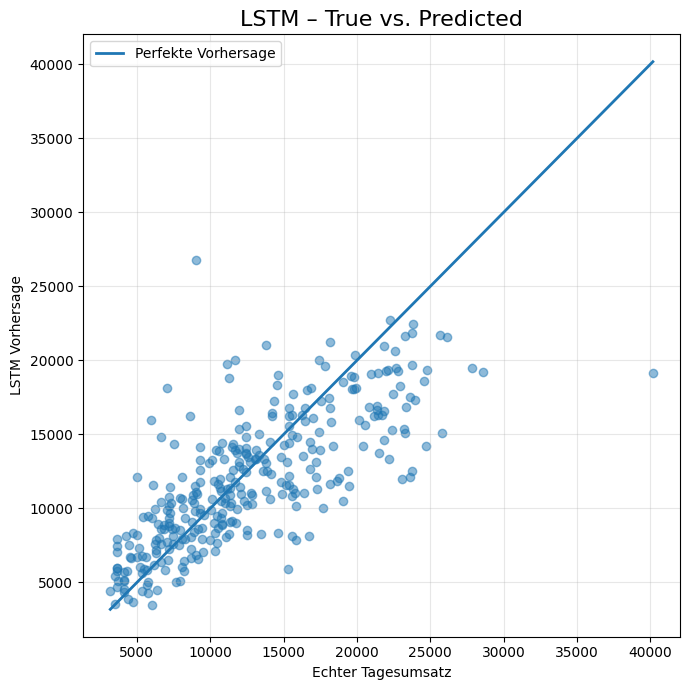

In [7]:

target_col = "Tagesumsatz Restaurant"

# Index setzen, tägliche Frequenz & Lücken füllen
df = df.set_index("Datum").asfreq("D")
df = df.ffill().bfill()

# Nur numerische Spalten als potenzielle Features
num_cols = df.select_dtypes(include=["number"]).columns

# Feature-Spalten = alle numerischen Spalten (inkl. Ziel, wir trennen gleich)
feature_cols = list(num_cols)

print("Feature-Spalten:", feature_cols)
print("Zielvariable   :", target_col)

# Train/Test-Split anhand Datum
split_date = pd.Timestamp("2025-01-01")
train_df = df[df.index < split_date]
test_df  = df[df.index >= split_date]

print("Train length (Tage):", len(train_df))
print("Test length  (Tage):", len(test_df))

# ===================== 1.2) Skalierung =====================

# X-Scaler: alle Features
scaler_X = MinMaxScaler()
X_train_raw = train_df[feature_cols].values
scaler_X.fit(X_train_raw)

X_all_scaled = scaler_X.transform(df[feature_cols].values)

# y-Scaler: nur Zielvariable
scaler_y = MinMaxScaler()
y_train_raw = train_df[[target_col]].values
scaler_y.fit(y_train_raw)

y_all_scaled = scaler_y.transform(df[[target_col]].values).flatten()

dates = df.index

# ===================== 2) Sliding-Window-Datensatz =====================

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
dates_test = []

n_samples = len(df)

for i in range(window_size, n_samples):
    # Sequenz der Features der letzten window_size Tage
    X_seq = X_all_scaled[i - window_size:i, :]     # (window_size, n_features)
    # Ziel: Zielvariable am Tag i (skaliert)
    y_target = y_all_scaled[i]
    target_date = dates[i]

    if target_date < split_date:
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    else:
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

# LSTM-Input: (samples, timesteps, features)
# X hat bereits Form (samples, window_size, n_features) → passt
n_features = X_train.shape[2]

print("X_train shape:", X_train.shape)  # (N_train, 30, n_features)
print("X_test shape :", X_test.shape)   # (N_test, 30, n_features)
print("Anzahl Features:", n_features)

# ===================== 3) PyTorch Dataset & DataLoader =====================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

# ===================== 4) LSTM-Modell definieren =====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor(input_size=n_features).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===================== 5) Training =====================

epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Train Loss: {epoch_loss:.6f}")

# ===================== 6) Vorhersage auf Testset =====================

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala (nur Zielvariable)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# ===================== 7) Metriken =====================

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

# naive Baseline: Vortag (auf Originalskala)
ts = df[target_col]            # vollständige Serie des Ziels
ts_shifted = ts.shift(1)
y_naive = ts_shifted.loc[dates_test].values
y_naive = pd.Series(y_naive, index=dates_test).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred)

print("\n--- METRIKEN (PyTorch LSTM mit Features) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ===================== 8) Plots =====================

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label="Ist-Umsatz", linewidth=2)
plt.plot(dates_test, y_pred, label="LSTM Vorhersage", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train length (gesamt vor 2025): 1461
Test length                   : 320
Val start date: 2024-03-14 00:00:00
X_train shape: (1138, 30, 1)
X_val shape  : (293, 30, 1)
X_test shape : (320, 30, 1)
Using device: cpu
Epoch 1/100 - Train Loss: 0.032510 - Val Loss: 0.027939
Epoch 2/100 - Train Loss: 0.018457 - Val Loss: 0.022076
Epoch 3/100 - Train Loss: 0.013378 - Val Loss: 0.021744
Epoch 4/100 - Train Loss: 0.012285 - Val Loss: 0.019843
Epoch 5/100 - Train Loss: 0.013020 - Val Loss: 0.020075
Epoch 6/100 - Train Loss: 0.012272 - Val Loss: 0.020820
Epoch 7/100 - Train Loss: 0.012251 - Val Loss: 0.019692
Epoch 8/100 - Train Loss: 0.012012 - Val Loss: 0.019320
Epoch 9/100 - Train Loss: 0.011880 - Val Loss: 0.020108
Epoch 10/100 - Train Loss: 0.011973 - Val Loss: 0.019413
Epoch 11/100 - Train Loss: 0.011791 - Val Loss: 0.019417
Epoch 12/100 - Train Loss: 0.011778 - Val Loss: 0.019513
Epoch 13/100 - Train Loss: 0.011766 - Val Loss: 0.019906
Epoch 14/100 - Train Loss: 0.011826 - Val Loss: 0.020299

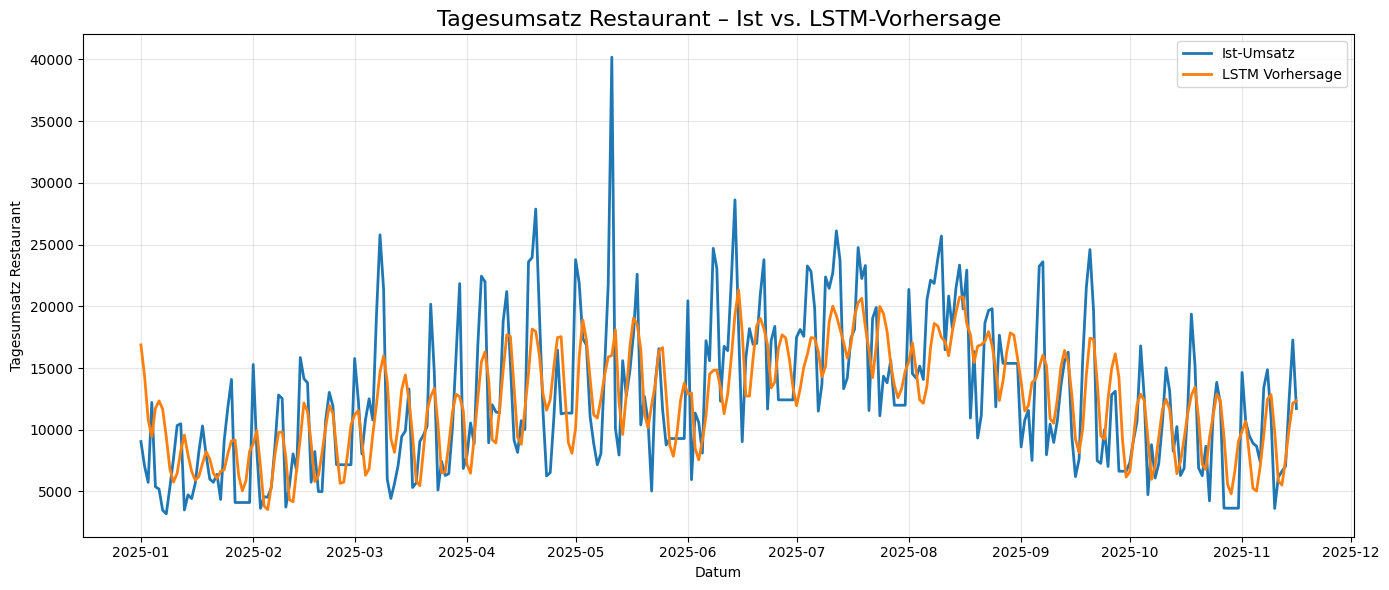

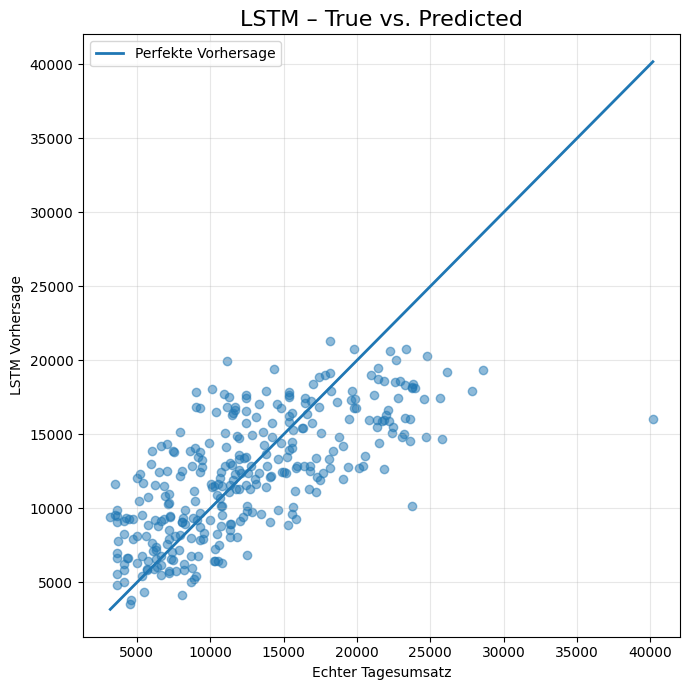

In [8]:


# ===================== 1) Daten laden & vorbereiten =====================

df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Univariate Zeitreihe
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# tägliche Frequenz & Lücken füllen
ts = ts.asfreq("D")
ts = ts.ffill().bfill()

# Äusseres Train/Test-Split
split_date = pd.Timestamp("2025-01-01")
train_full = ts[ts.index < split_date]
test       = ts[ts.index >= split_date]

print("Train length (gesamt vor 2025):", len(train_full))
print("Test length                   :", len(test))

# ===================== 1.2) Inneres Train/Val-Split (zeitlich)  =====================
# NEU: wir nehmen z.B. die letzten 20% der Trainingsdaten als Validation

val_fraction = 0.2
val_start_idx = int(len(train_full) * (1 - val_fraction))
train_inner   = train_full.iloc[:val_start_idx]
val           = train_full.iloc[val_start_idx:]

val_start_date = val.index[0]
print("Val start date:", val_start_date)

# Skaler NUR auf inneres Training anpassen
scaler = MinMaxScaler()
scaler.fit(train_inner.values.reshape(-1, 1))  # NEU: nicht auf val/test

# gesamte Serie mit demselben Skaler transformieren
full_scaled = scaler.transform(ts.values.reshape(-1, 1)).flatten()
dates = ts.index

# ===================== 2) Sliding-Window-Datensatz =====================

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []   # NEU
X_test_list,  y_test_list  = [], []
dates_test = []

for i in range(window_size, len(full_scaled)):
    X_seq = full_scaled[i - window_size:i]
    y_target = full_scaled[i]
    target_date = dates[i]

    if target_date < val_start_date:
        # inneres Training
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    elif target_date < split_date:
        # Validation
        X_val_list.append(X_seq)
        y_val_list.append(y_target)
    else:
        # Test
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_val   = np.array(X_val_list)
y_val   = np.array(y_val_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

# LSTM-Input: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0],   X_val.shape[1],   1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1],  1))

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

# ===================== 3) PyTorch Dataset & DataLoader =====================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val,   y_val)
test_dataset  = TimeSeriesDataset(X_test,  y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)  # NEU
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

# ===================== 4) LSTM-Modell definieren =====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):  # NEU: dropout
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0  # NEU
        )
        self.dropout = nn.Dropout(dropout)  # NEU: zusätzlich nach LSTM
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe
        last_out = self.dropout(last_out)  # NEU
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3, weight_decay=1e-4  # NEU: L2-regularization (Ridge-Style)
)

# ===================== 5) Training mit Validation & Early Stopping =====================

epochs = 100
patience = 10  # wie viele Epochen ohne Verbesserung wir warten
best_val_loss = float("inf")
patience_counter = 0
best_state_dict = None

for epoch in range(1, epochs + 1):
    # ----- Training -----
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(-1)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    # Early Stopping Logik
    if val_loss < best_val_loss - 1e-5:  # kleiner Toleranzschritt
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

# bestes Modell wiederherstellen
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# ===================== 6) Vorhersage auf Testset =====================

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# ===================== 7) Metriken =====================

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

# naive Baseline: Vortag
ts_shifted = ts.shift(1)
y_naive = ts_shifted.loc[dates_test].values
y_naive = pd.Series(y_naive, index=dates_test).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred)

print("\n--- METRIKEN (PyTorch LSTM mit Val & Early Stopping) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ===================== 8) Plots =====================

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label="Ist-Umsatz", linewidth=2)
plt.plot(dates_test, y_pred, label="LSTM Vorhersage", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train length (vor 2025): 1461
Test length           : 320
Validation beginnt am: 2024-08-07
X_train shape: (1284, 30, 4)
X_val shape  : (147, 30, 4)
X_test shape : (320, 30, 4)
Anzahl Features pro Zeitschritt: 4
Using device: cpu
Epoch 1/80 - Train Loss: 0.021430 - Val Loss: 0.015541
Epoch 2/80 - Train Loss: 0.011886 - Val Loss: 0.012693
Epoch 3/80 - Train Loss: 0.010389 - Val Loss: 0.011839
Epoch 4/80 - Train Loss: 0.009528 - Val Loss: 0.011350
Epoch 5/80 - Train Loss: 0.008743 - Val Loss: 0.013216
Epoch 6/80 - Train Loss: 0.008798 - Val Loss: 0.011210
Epoch 7/80 - Train Loss: 0.007956 - Val Loss: 0.012369
Epoch 8/80 - Train Loss: 0.008440 - Val Loss: 0.010568
Epoch 9/80 - Train Loss: 0.007574 - Val Loss: 0.010385
Epoch 10/80 - Train Loss: 0.006946 - Val Loss: 0.009946
Epoch 11/80 - Train Loss: 0.006716 - Val Loss: 0.010810
Epoch 12/80 - Train Loss: 0.006544 - Val Loss: 0.009677
Epoch 13/80 - Train Loss: 0.006318 - Val Loss: 0.009408
Epoch 14/80 - Train Loss: 0.006254 - Val Loss: 0.00

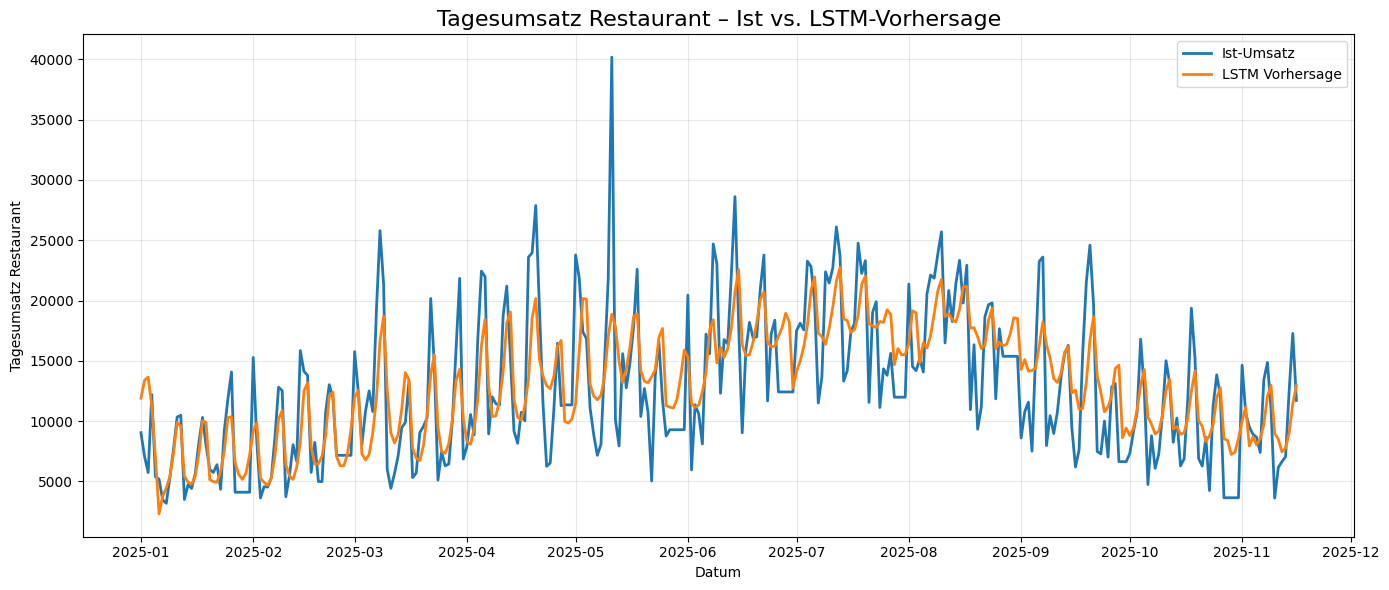

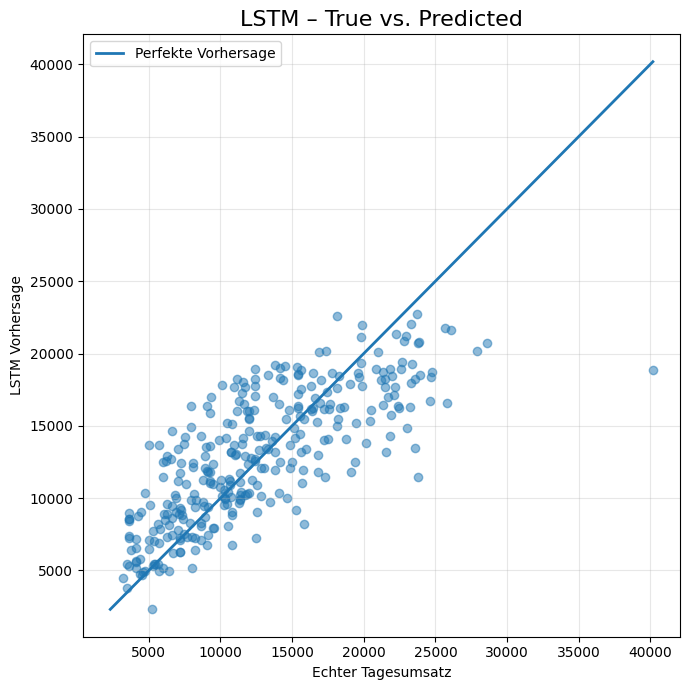

In [ ]:

# ===================== Reproduzierbarkeit =====================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ===================== 1) Daten laden & vorbereiten =====================

df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst Data Leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Zielvariable (Tagesumsatz)
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# tägliche Frequenz & Lücken füllen
ts = ts.asfreq("D")
ts = ts.ffill().bfill()

# Kalender-Features hinzufügen
calendar_df = pd.DataFrame(index=ts.index)
calendar_df["weekday"]    = calendar_df.index.weekday      # 0=Montag,...,6=Sonntag
calendar_df["month"]      = calendar_df.index.month        # 1-12
calendar_df["is_weekend"] = (calendar_df["weekday"] >= 5).astype(int)

# Feature-Matrix + Target in einem DataFrame
data = pd.DataFrame({
    "umsatz": ts.values
}, index=ts.index)
data = pd.concat([data, calendar_df], axis=1)

# Äußeres Train/Test-Split (Zeitreihen-sicher)
split_date = pd.Timestamp("2025-01-01")
train_full = data[data.index < split_date].copy()
test       = data[data.index >= split_date].copy()

print("Train length (vor 2025):", len(train_full))
print("Test length           :", len(test))

# ===================== 1.2) Skaler auf Trainingsumsatz =====================
# Skalieren NUR die Zielvariable, nicht die Kalender-Features

scaler = MinMaxScaler()
scaler.fit(train_full["umsatz"].values.reshape(-1, 1))

# komplette Serie transformieren (nur Zielspalte)
umsatz_scaled_full = scaler.transform(data["umsatz"].values.reshape(-1, 1)).flatten()

# Features-Array (nicht skaliert): weekday, month, is_weekend
feat_array = data[["weekday", "month", "is_weekend"]].values

dates = data.index

# ===================== 1.3) Inneres Train/Validation innerhalb von train_full =====================

val_fraction = 0.1  # 10% der Trainingszeit als Validation
n_train_full = len(train_full)
val_start_idx = int(n_train_full * (1 - val_fraction))
val_start_date = train_full.index[val_start_idx]

print("Validation beginnt am:", val_start_date.date())

# ===================== 2) Sliding-Window-Datensätze (Train / Val / Test) =====================

window_size = 30  # wie viele Tage zurück das LSTM sehen soll

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []
dates_test = []

for i in range(window_size, len(dates)):
    target_date = dates[i]

    # Input-Sequenz: Umsatz (skaliert) + Kalender-Features
    seq_umsatz = umsatz_scaled_full[i - window_size:i]             # (window_size,)
    seq_feats  = feat_array[i - window_size:i, :]                  # (window_size, 3)
    # Sequenz zusammen: (window_size, 1 + 3) = (window_size, 4)
    X_seq = np.column_stack([seq_umsatz.reshape(-1, 1), seq_feats])

    # Ziel: skalierten Umsatz des Tages i vorhersagen
    y_target = umsatz_scaled_full[i]

    if target_date < val_start_date:
        X_train_list.append(X_seq)
        y_train_list.append(y_target)
    elif target_date < split_date:
        X_val_list.append(X_seq)
        y_val_list.append(y_target)
    else:
        X_test_list.append(X_seq)
        y_test_list.append(y_target)
        dates_test.append(target_date)

X_train = np.array(X_train_list)   # (n_train, window_size, n_features)
y_train = np.array(y_train_list)
X_val   = np.array(X_val_list)
y_val   = np.array(y_val_list)
X_test  = np.array(X_test_list)
y_test_scaled = np.array(y_test_list)
dates_test = np.array(dates_test)

n_features = X_train.shape[2]

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)
print("Anzahl Features pro Zeitschritt:", n_features)

# ===================== 3) PyTorch Dataset & DataLoader =====================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val,   y_val)
test_dataset  = TimeSeriesDataset(X_test,  y_test_scaled)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset), shuffle=False)

# ===================== 4) LSTM-Modell definieren =====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)           # (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]        # letzte Zeitstufe (batch, hidden_size)
        out = self.fc(last_out)         # (batch, 1)
        return out

model = LSTMRegressor(input_size=n_features, hidden_size=64, num_layers=2, dropout=0.0).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===================== 5) Training mit Validation & Early Stopping =====================

epochs = 80
patience = 10
best_val_loss = float("inf")
patience_counter = 0
best_state_dict = None

for epoch in range(1, epochs + 1):
    # ----- Training -----
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # (batch, 1)

        optimizer.zero_grad()
        outputs = model(X_batch)                    # (batch, 1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(-1)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    # Early Stopping
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping nach Epoch {epoch}")
            break

# bestes Modell laden
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# ===================== 6) Vorhersage auf Testset =====================

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred_scaled_tensor = model(X_test_tensor)   # (n_test, 1)
    y_pred_scaled = y_pred_scaled_tensor.cpu().numpy().flatten()

# zurück in Originalskala (nur Zielvariable)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# ===================== 7) Metriken =====================

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

# naive Baseline: Vortag
ts_full = ts  # Original-Zeitreihe der Umsätze
ts_shifted = ts_full.shift(1)
y_naive = ts_shifted.loc[dates_test].values
y_naive = pd.Series(y_naive, index=dates_test).bfill().values

mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred)

print("\n--- METRIKEN (LSTM mit Kalender-Features & Early Stopping) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}  (LSTM / naive)")
print(f"MAPE         : {mape_value:.2f}%")

# ===================== 8) Plots =====================

# Zeitreihen-Plot
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label="Ist-Umsatz", linewidth=2)
plt.plot(dates_test, y_pred, label="LSTM Vorhersage", linewidth=2)
plt.title("Tagesumsatz Restaurant – Ist vs. LSTM-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter-Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("LSTM – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("LSTM Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
